
### 1. **Regresión: SHAP con el conjunto de datos California Housing**

#### a) **Gráfico de Resumen (Summary Plot)**

Este es uno de los gráficos más importantes porque te da una visión general del impacto de todas las características sobre las predicciones del modelo.


In [ ]:
!pip install shap
!pip install xgboost

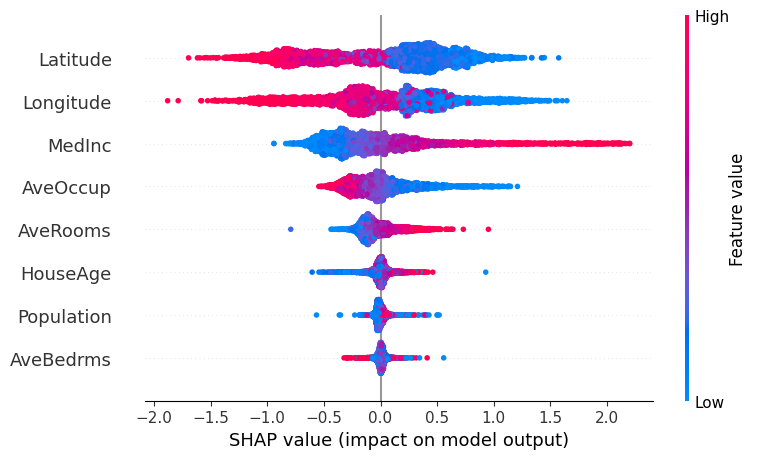

In [ ]:
import shap
import xgboost
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing


# Cargar datos
X, y = fetch_california_housing(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar modelo XGBoost
model = xgboost.XGBRegressor().fit(X_train, y_train)

# Crear el explicador SHAP
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Gráfico resumen
shap.summary_plot(shap_values, X_test)


- **Interpretación**: Cada punto representa un valor SHAP para una característica en una instancia de prueba. Las características se ordenan de acuerdo a su importancia, de arriba hacia abajo. Los puntos en rojo representan valores altos de las características, y los azules, valores bajos. Si un punto está a la derecha del centro, eso indica que la característica aumenta la predicción (contribuye positivamente). A la izquierda, disminuye la predicción (contribuye negativamente).

Por ejemplo:

- MedInc: Los puntos rojos en el gráfico, que representan valores altos de ingreso, tienden a tener un valor SHAP positivo, lo que significa que en zonas con ingresos medios altos, el precio de las casas aumenta. Los puntos azules (ingresos bajos) tienen valores SHAP negativos, lo que sugiere que en áreas de ingresos bajos, el valor de las casas disminuye.

- Latitude y Longitude: Las latitudes más altas (norte) y longitudes más bajas (oeste), que generalmente corresponden a ubicaciones cercanas a la costa, tienden a tener un valor SHAP positivo, lo que indica que estas ubicaciones aumentan el precio de las casas.



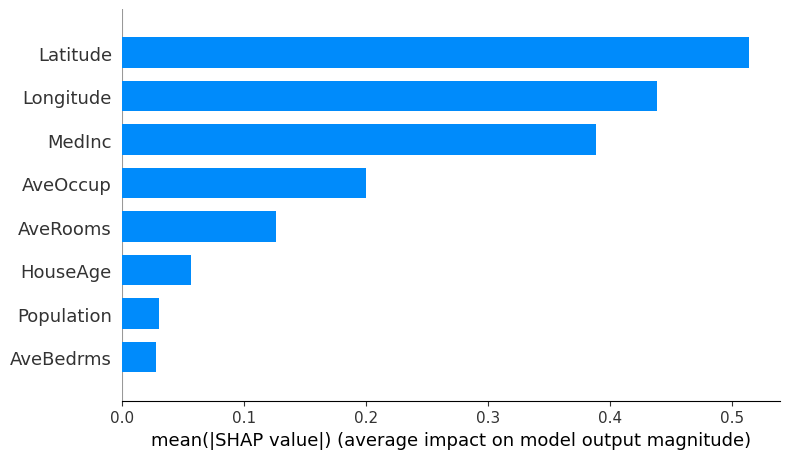

In [ ]:
# Gráfico de barras de importancia de características
shap.summary_plot(shap_values, X_test, plot_type="bar")


In [ ]:

# Calcular la importancia de cada característica como el valor promedio absoluto de los SHAP values
feature_importance = np.abs(shap_values_array).mean(axis=0)

# Crear un DataFrame para visualizar mejor los resultados
feature_importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': feature_importance
})

# Ordenar las características por importancia
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Mostrar la importancia de las características
print(feature_importance_df)


      feature  importance
6    Latitude    0.513812
7   Longitude    0.438895
0      MedInc    0.388388
5    AveOccup    0.200593
2    AveRooms    0.126703
1    HouseAge    0.056558
4  Population    0.030340
3   AveBedrms    0.027894


####  b) **Dependence Plot**
Este gráfico muestra la relación entre una característica específica y su valor SHAP. Es útil para ver cómo cambia el impacto de una característica a medida que varían sus valores. También puedes visualizar las interacciones entre características.

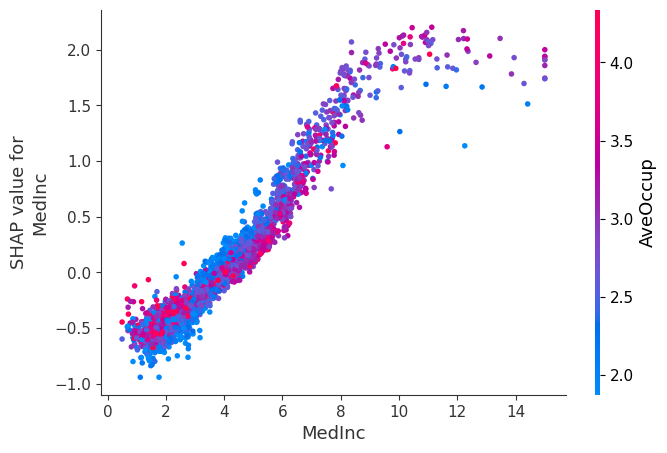

In [ ]:
# Extraer los valores SHAP para la dependencia
shap_values_array = shap_values.values  # Extraer la matriz de valores SHAP

# Gráfico de dependencia para la característica 'MedInc'
shap.dependence_plot('MedInc', shap_values_array, X_test)



- **Interpretación**: El eje X es el valor de la característica 'MedInc' (por ejemplo, el ingreso medio), y el eje Y es el valor SHAP. Puedes observar cómo 'MedInc' afecta las predicciones a medida que varía. En este gráfico, también puedes ver las interacciones entre 'MedInc' y otra característica (mostrada en color), como el número de habitaciones promedio.

Este gráfico de dependencia muestra cómo la característica **MedInc** (Ingreso Medio) afecta las predicciones del modelo de precios de vivienda en California y revela además la interacción con otra característica: **AveOccup** (Ocupación Promedio). Vamos a desglosarlo:

### 1. **Eje X: MedInc (Ingreso Medio)**
El eje X representa los valores de la característica *MedInc* (Ingreso Medio en la zona), que varían de 0 a 15 aproximadamente. Estos valores reflejan los ingresos promedios de las familias en las diferentes áreas de California.

### 2. **Eje Y: SHAP values for MedInc**
El eje Y representa los valores SHAP para la característica *MedInc*, que indican cuánto contribuye esa característica al precio final de la vivienda (en términos de desviación sobre la predicción promedio del modelo). Valores SHAP positivos implican un incremento en el valor predicho de las viviendas, mientras que valores negativos indican una disminución.

### 3. **Color: Interacción con AveOccup (Ocupación Promedio)**
El color de los puntos refleja el valor de una segunda característica, **AveOccup** (Ocupación Promedio).
- **Rojo** indica valores más altos de ocupación promedio, es decir, áreas con más ocupación por hogar.
- **Azul** indica valores más bajos de ocupación promedio.

### Interpretación del gráfico:

1. **Relación directa entre *MedInc* y los precios de las casas**:
   - Vemos una clara relación positiva entre *MedInc* y los valores SHAP, lo que significa que, a medida que aumenta el ingreso medio en la zona, el valor predicho de las viviendas también aumenta. Esto tiene sentido intuitivamente, ya que las áreas con mayores ingresos suelen tener viviendas más caras.
   - En la región con *MedInc* menor a 6, la relación es más lineal: a mayor ingreso medio, mayor el efecto positivo en el precio de la vivienda.
   - Para *MedInc* mayores a 10, la relación parece saturarse, lo que indica que, una vez que los ingresos superan cierto umbral, su efecto sobre el precio de la vivienda es menos pronunciado.

2. **Interacción con AveOccup (Ocupación Promedio)**:
   - Las interacciones entre *MedInc* y *AveOccup* también se hacen evidentes. Para las zonas de ingreso medio bajo (valores pequeños de *MedInc*), los hogares con alta ocupación (puntos rojos) tienden a tener un impacto más negativo sobre el valor de las viviendas, ya que los valores SHAP tienden a ser menores.
   - A medida que el ingreso medio aumenta, el color de los puntos (rojo vs. azul) parece no tener un impacto tan grande, lo que sugiere que el efecto de *AveOccup* es más importante en las zonas de ingreso bajo. En estas zonas, una ocupación más baja (puntos azules) tiene un impacto más positivo sobre los precios de las viviendas.

3. **Distribución y patrones**:
   - La nube de puntos sigue un patrón claro que confirma la importancia de *MedInc* en el modelo. A medida que *MedInc* aumenta, los valores SHAP tienden a moverse hacia valores más positivos, lo que confirma que los hogares en áreas de mayor ingreso contribuyen de manera más positiva a los precios predichos por el modelo.
   - Este gráfico sugiere que *MedInc* es una característica clave y que el modelo detecta una relación no lineal entre esta característica y el valor predicho de las viviendas, especialmente cuando el ingreso supera cierto umbral.

Este gráfico muestra que el ingreso medio es una característica dominante en la predicción del precio de las viviendas en California. A medida que aumenta *MedInc*, también lo hace el precio de las viviendas, con una ligera saturación en niveles muy altos de ingreso. La ocupación promedio (AveOccup) tiene un impacto más relevante en áreas con ingresos bajos, donde los hogares con alta ocupación parecen reducir los valores de las viviendas.



#### c) **Force Plot**

El gráfico de fuerza es ideal para explicar cómo se construye una predicción individual. Vamos a ver un ejemplo para una instancia específica.


In [ ]:
!pip install jupyterlab shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.0/78.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.1/106.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 3.9 MB/s eta 0:00:00
  Attempting uninstall: jupyter-client
    Found existing installation: jupyter-client 6.1.12
    Uninstalling jupyter-client-6.1.12:
 

In [ ]:
# Cargar la librería de JavaScript para SHAP
shap.initjs()


# Gráfico de fuerza para la primera instancia
shap.force_plot(shap_values[10], X_test.iloc[10])



- **Interpretación**: En este gráfico, la predicción para la instancia se muestra como un valor que se empuja desde el valor base del modelo (la predicción promedio). Las características que aumentan la predicción empujan hacia la derecha, mientras que las que la disminuyen empujan hacia la izquierda.


Este gráfico de fuerza de SHAP te muestra cómo las diferentes características de una instancia específica (en este caso, la instancia número 10) afectan la predicción del modelo. Vamos a desglosar los elementos clave del gráfico y lo que nos dicen sobre esta predicción:

### Elementos del gráfico:

1. **Base value** (valor base):
   - **2.072**: Este es el valor promedio de las predicciones del modelo, es decir, el valor al que se llegaría si no se consideraran las características individuales de esta instancia. En el contexto del problema de regresión de precios de viviendas, representa el precio promedio (en logaritmos) de las viviendas según el modelo.

2. **f(x)** (predicción):
   - **1.052**: Esta es la predicción del modelo para la instancia 10. El valor predicho es menor que el valor base, lo que significa que el modelo predice un valor más bajo para esta casa en comparación con el promedio.

3. **Contribuciones de las características**:
   - Las barras rojas y azules muestran cómo las características individuales contribuyen a empujar la predicción hacia arriba o hacia abajo, partiendo del valor base.
   - **Barras rojas**: Representan características que **aumentan** el valor predicho (empujan la predicción hacia la derecha, hacia un valor más alto).
   - **Barras azules**: Representan características que **disminuyen** el valor predicho (empujan la predicción hacia la izquierda, hacia un valor más bajo).

### Interpretación de las características específicas:

- **Longitude = -120.4**:
   - Este valor empuja la predicción hacia abajo (barra roja), lo que indica que la longitud tiene un impacto negativo en el valor predicho. En otras palabras, estar ubicado en esta longitud específica disminuye el precio de la vivienda.
   
- **Latitude = 38.01**:
   - Similarmente, la latitud tiene un impacto negativo en la predicción (barra azul). Esto sugiere que estar en esta latitud en particular disminuye el valor predicho para esta instancia.

- **MedInc = 2.542** (Ingreso medio):
   - El ingreso medio tiene un efecto negativo (barra azul) en la predicción del valor de la vivienda, lo que sugiere que esta zona tiene un ingreso relativamente bajo, lo que reduce el valor de la casa en comparación con el promedio.

- **AveRooms = 5.086** (Habitaciones promedio por hogar):
   - Esta característica tiene un efecto positivo (barra azul más pequeña), pero aún disminuye la predicción. Aunque el número promedio de habitaciones parece ser considerable, no es suficiente para aumentar el precio de la vivienda significativamente en este caso.


- El valor base es 2.072 (el precio promedio predicho por el modelo), pero debido a las características específicas de la ubicación de esta casa (como la longitud y latitud), así como el ingreso medio de la zona, el valor predicho es **1.052**.
- Las características que más contribuyen a disminuir el valor predicho son la **longitud** y **latitud** (ubicación), mientras que el **ingreso medio** y el **número de habitaciones promedio** también contribuyen a una ligera disminución.




#### d) **Waterfall Plot**

El gráfico waterfall es una versión detallada del force plot, mostrando cómo cada característica contribuye al resultado final de la predicción.

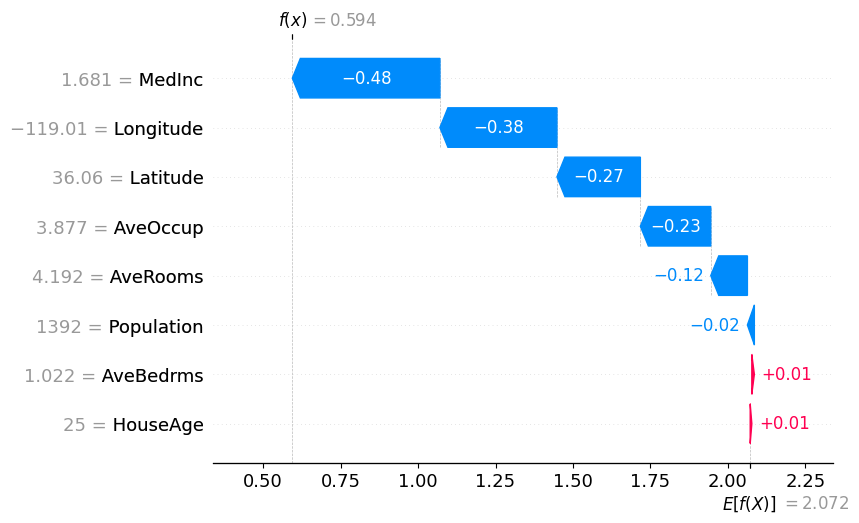

In [ ]:
# Gráfico waterfall para la primera instancia
shap.plots.waterfall(shap_values[0])


- **Interpretación**: Muestra cómo cada característica afecta una predicción individual de manera acumulativa. Este gráfico es útil para ver el impacto de cada característica de manera ordenada, empezando desde el valor base y sumando o restando los valores SHAP.



#### e) **Decision Plot**

Este gráfico te muestra cómo evoluciona la predicción a medida que el modelo toma en cuenta más características. Es útil para ver cómo el modelo ajusta la predicción paso a paso.


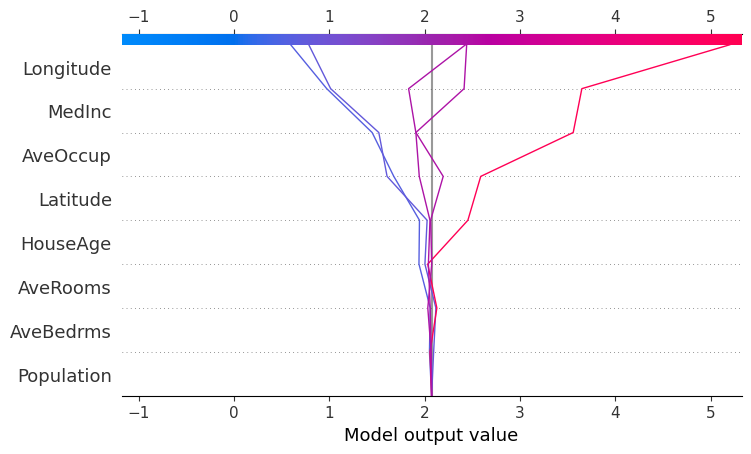

In [ ]:
# Gráfico de decisión
shap.decision_plot(explainer.expected_value, shap_values_array[0:5], X_test.iloc[0:5])


- **Interpretación**: El gráfico muestra cómo el modelo pasa de la predicción base (esperada) a la predicción final a medida que evalúa cada característica en orden de importancia. Puedes seguir las líneas para cada una de las instancias y ver cómo cada característica influye.




### Componentes del gráfico:

1. **Eje horizontal (Model output value)**:
   - Este eje muestra los valores de salida del modelo, que representan las predicciones finales de cada instancia.
   - Cada línea sigue la evolución de una instancia desde el valor base hasta su predicción final, a medida que el modelo incorpora más características.

2. **Eje vertical (Características)**:
   - Las características están ordenadas de acuerdo a su importancia en el modelo. Las más importantes están en la parte superior, como **Longitude**, **MedInc**, y **AveOccup**, y las menos importantes, como **Population**, en la parte inferior.

3. **Líneas de colores**:
   - Cada línea representa una instancia distinta del conjunto de datos. El color de las líneas varía de azul a rojo, donde el color azul indica predicciones más bajas y el color rojo indica predicciones más altas.
   - Estas líneas muestran cómo la predicción de cada instancia se va ajustando (moviendo hacia la derecha o izquierda) a medida que se consideran más características.

### Interpretación del gráfico:

1. **Valor base (Base value)**:
   - Todas las líneas comienzan en un valor común cercano a 2 en el eje horizontal. Este es el valor base del modelo, que es el valor promedio de las predicciones cuando no se han incorporado características específicas de las instancias.

2. **Efecto de las características en la predicción**:
   - **Longitude** y **MedInc** son las primeras características evaluadas. Observa cómo varias líneas tienen grandes saltos cuando estas dos características se incorporan, lo que indica que tienen un impacto significativo en la predicción.
     - Algunas líneas se mueven hacia la izquierda, lo que significa que estas características disminuyen el valor de predicción para esas instancias (azul), mientras que otras se mueven hacia la derecha, aumentando el valor de predicción (rojo).
   - **AveOccup** (Ocupación promedio) también tiene un impacto importante, como se puede ver en la continuación del ajuste de las líneas.
   - A medida que las características menos importantes, como **Population** y **AveBedrms**, se evalúan, las líneas se estabilizan, lo que indica que estas características tienen un impacto mucho menor en las predicciones.

3. **Diferencias entre las instancias**:
   - Las líneas no siguen el mismo patrón, lo que indica que las características afectan de manera diferente a cada instancia. Esto refleja la diversidad de las instancias en términos de sus valores de características.
   - Por ejemplo, algunas instancias (líneas rojas) tienen predicciones finales mucho más altas, mientras que otras (líneas azules) terminan con predicciones más bajas, lo que indica que las características específicas para esas instancias influyen de manera diferente.

4. **Comportamiento de las características**:
   - **Longitude** y **MedInc** parecen ser las características más influyentes en el cambio inicial de las predicciones. En algunas instancias, como se puede ver en el gráfico, estas características tienen un efecto muy fuerte y ajustan rápidamente la predicción.
   - Las características **Latitude**, **HouseAge** y **AveRooms** también tienen efectos más pequeños, pero siguen contribuyendo al ajuste de las predicciones a medida que se consideran.

Este gráfico ilustra cómo el modelo ajusta las predicciones en cada instancia a medida que evalúa características clave. Puedes ver cómo algunas características, como **Longitude** y **MedInc**, tienen un gran impacto en las predicciones de las instancias, mientras que otras tienen un impacto mucho menor. La interpretación general de este gráfico es que las primeras características consideradas (en la parte superior) son las que más influyen en las predicciones, y las características más abajo tienen un impacto menor, pero aún pueden ajustar las predicciones finales.

---

### 2. **Clasificación: SHAP con el conjunto de datos de cáncer de mama**

#### a) **Gráfico de Resumen (Summary Plot)**

Igual que en regresión, este gráfico te ofrece una visión general de cómo las características afectan la clasificación del modelo.


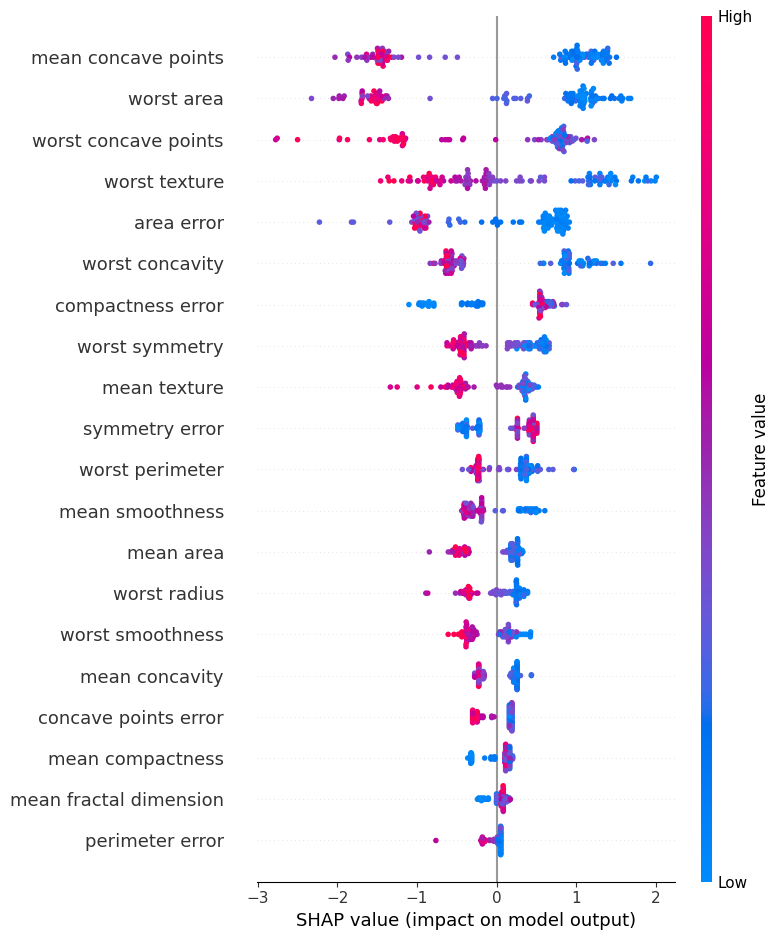

In [ ]:
from sklearn.datasets import load_breast_cancer
X, y = load_breast_cancer(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgboost.XGBClassifier().fit(X_train, y_train)

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)


- **Interpretación**: Aquí puedes ver qué características están ayudando al modelo a clasificar las instancias como benignas o malignas. Las características más arriba tienen más impacto en la clasificación. Los valores SHAP positivos indican que aumentan la probabilidad de pertenecer a una clase en particular (en este caso, maligno o benigno).

#### 1. **mean concave points** (puntos cóncavos promedio):
   - Esta es la característica más importante según el gráfico. Los puntos en el lado derecho (con valores SHAP positivos) sugieren que cuando el valor de **mean concave points** es **alto** (color rojo), tiende a empujar la predicción hacia la **clase 1** (maligno).
   - Los puntos en el lado izquierdo (valores SHAP negativos) muestran que cuando **mean concave points** es **bajo** (color azul), tiende a empujar la predicción hacia la **clase 0** (benigno).

#### 2. **worst area** (área más grande):
   - También tiene un impacto significativo en las predicciones. Un **área grande** (puntos rojos en el lado derecho) tiende a asociarse con una mayor probabilidad de tumor **maligno**, mientras que un **área pequeña** (puntos azules en el lado izquierdo) se asocia con una mayor probabilidad de ser **benigno**.

#### 3. **worst concave points** (puntos cóncavos más grandes):
   - Los valores altos de **worst concave points** (en rojo) también empujan la predicción hacia la clase de tumor **maligno**, mientras que los valores bajos (en azul) tienden a empujar hacia la clase **benigna**.

#### 4. **Interacciones entre características**:
   - Observa cómo algunas características (como **mean concave points**, **worst area**) tienen una dispersión considerable de puntos, lo que indica que su impacto en las predicciones puede variar mucho dependiendo de su valor. Esto sugiere que las características tienen una **relación no lineal** con la probabilidad de que el tumor sea maligno o benigno.

#### 5. **Simetría y textura**:
   - Características como **symmetry error** y **mean texture** tienen un impacto menos marcado en las predicciones, pero siguen contribuyendo al ajuste del modelo. Valores altos de **mean texture** tienden a aumentar la probabilidad de malignidad (lado derecho), aunque no con tanta fuerza como las características más importantes.

### Resumen:

- **Las características más importantes**: Las primeras tres características, **mean concave points**, **worst area**, y **worst concave points**, son las más influyentes. Cuando estas tienen valores altos (color rojo), tienden a empujar la predicción hacia la clase **maligna**.
- **Características con menor impacto**: Características como **mean fractal dimension** y **perimeter error** tienen un impacto más moderado y aparecen más abajo en el gráfico.
- **Variabilidad de los valores SHAP**: El ancho de la dispersión para cada característica te indica cuánta variabilidad tiene el impacto de esa característica en las predicciones. Cuanto más dispersos están los puntos a lo largo del eje X, más variable es el impacto de esa característica.

Este gráfico te permite ver de forma clara cómo cada característica afecta las predicciones del modelo y cómo los diferentes valores de las características contribuyen a empujar una predicción hacia **maligno (clase 1)** o **benigno (clase 0)**.





#### b) **Force Plot**

Como en el caso de regresión, este gráfico es ideal para explicar cómo las características individuales empujan la probabilidad hacia una clase u otra.


In [ ]:
# Cargar la librería de JavaScript para SHAP
shap.initjs()
# Gráfico de fuerza para una instancia de clasificación
shap.force_plot(shap_values[0], X_test.iloc[0])

In [ ]:
proba_manual= 1/(1+np.exp(-5.89))
proba_manual

0.9972406583371649

In [ ]:
# Obtener las probabilidades para la primera instancia del conjunto de prueba
probs = model.predict_proba(X_test.iloc[[0]].values) # Use .iloc to access the first row and .values to get the underlying NumPy array

# Probabilidad de la clase 0 (benigno) y clase 1 (maligno)
print("Probabilidad de clase 0 (benigno):", probs[0][0])
print("Probabilidad de clase 1 (maligno):", probs[0][1])

Probabilidad de clase 0 (benigno): 0.0027461648
Probabilidad de clase 1 (maligno): 0.99725384



- **Interpretación**: Este gráfico muestra cómo las características específicas contribuyen a clasificar una instancia como, por ejemplo, cáncer maligno o benigno. Los valores SHAP positivos aumentan la probabilidad de que sea maligno, y los negativos la disminuyen.

#### c) **Waterfall Plot**

Este gráfico también puede ser utilizado en clasificación para ver el impacto acumulado de las características en la probabilidad de clasificación.


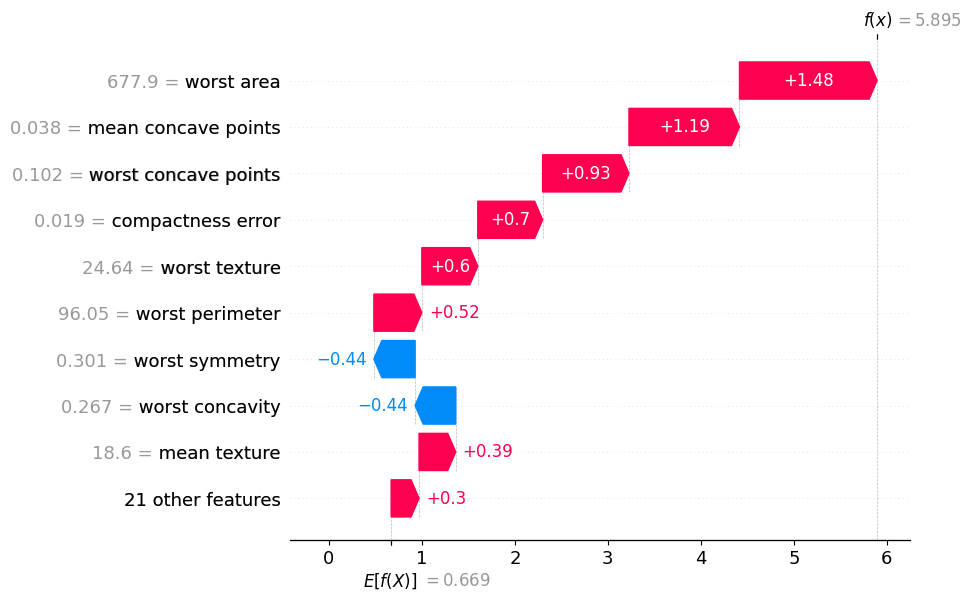

In [ ]:
# Gráfico waterfall para la primera instancia
shap.plots.waterfall(shap_values[0])


- **Interpretación**: En clasificación, este gráfico muestra cómo las características influyen en el valor de probabilidad final. Por ejemplo, si el modelo predice cáncer maligno, el gráfico mostrará cómo cada característica empuja esa predicción hacia arriba o hacia abajo.

#### d) **Decision Plot**

Es especialmente útil para ver cómo las características clave van ajustando las predicciones a medida que el modelo considera más información.


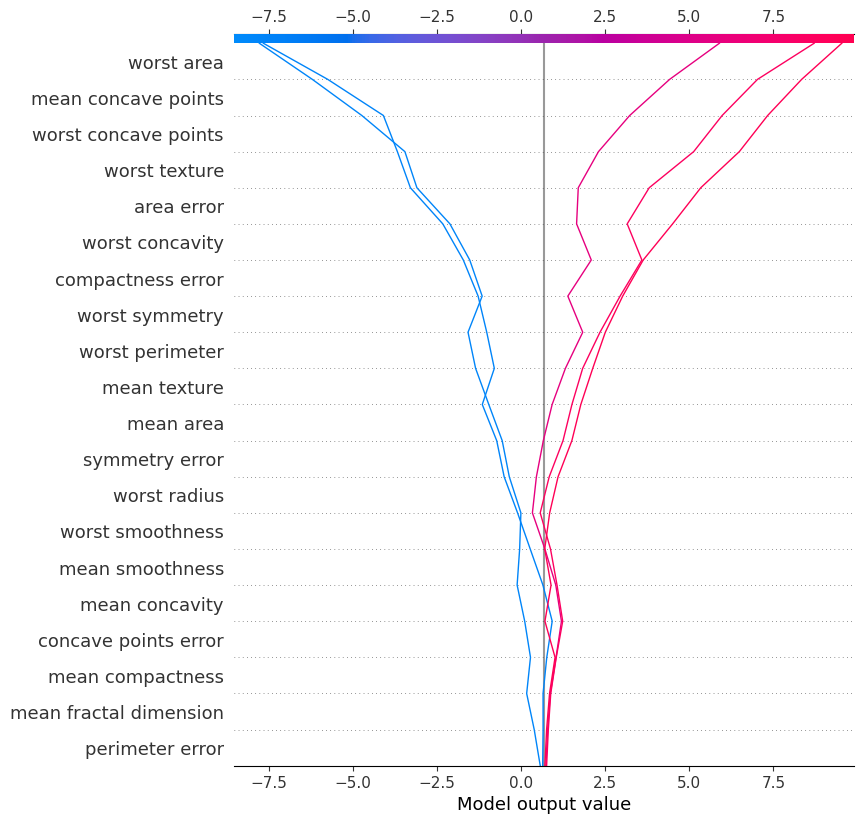

In [ ]:
# Extraer los valores SHAP en el formato adecuado
shap_values_array = shap_values.values

# Asegurarse de que los nombres de las características estén en formato de lista
feature_names = list(X_test.columns)

# Gráfico de decisión con los nombres de las características
shap.decision_plot(explainer.expected_value, shap_values_array[0:5], X_test.iloc[0:5], feature_names=feature_names)




- **Interpretación**: Aquí, puedes ver cómo el modelo va modificando la probabilidad de clasificación (por ejemplo, maligno vs. benigno) a medida que incorpora más características.